# Notebook 4 : Pipeline Complet

## Objectif
Ce dernier notebook assemble les briques technologiques développées précédemment (Détection, Clustering, Homographie) pour créer le produit final. Il intègre également la notion de "Tracking" pour suivre les identifiants des joueurs à travers le temps.

## 1. Initialisation
Nous chargeons les modèles et la matrice (définie précédemment).

In [5]:
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO
import pickle

# Chargement du K-Means
with open('kmeans_model.pkl', 'rb') as f:
    kmeans = pickle.load(f)

model = YOLO('yolov8m.pt')

H_MATRIX = np.array([[ 7.26506020e-02 , 1.38413022e-02 ,-3.28302648e+01],
 [ 1.54375879e-02 , 8.23253728e-02 ,-3.12342829e+01],
 [-6.94013147e-05 , 3.20403750e-04 , 1.00000000e+00]]) 

def get_player_color(image, bbox):
    x1, y1, x2, y2 = map(int, bbox)
    player_img = image[y1:y2, x1:x2]
    if player_img.size == 0: return [0,0,0]
    h, w, _ = player_img.shape
    center_img = player_img[int(h*0.3):int(h*0.7), int(w*0.3):int(w*0.7)]
    mean = cv2.resize(center_img, (1, 1), interpolation=cv2.INTER_AREA)[0][0]
    return mean

def transform_point(x, y, matrix):
    pts = np.array([[[x, y]]], dtype=np.float32)
    return cv2.perspectiveTransform(pts, matrix)[0][0]

## 2. Exécution sur la vidéo (Tracking)
Nous activons le mode `track` de YOLO pour suivre les IDs des joueurs.

In [6]:
cap = cv2.VideoCapture("input_video.mp4")
tracking_data = [] # Pour stocker les données finales

fps = int(cap.get(cv2.CAP_PROP_FPS))
start_time_seconds = 0
cap.set(cv2.CAP_PROP_POS_FRAMES, start_time_seconds * fps)

frame_count = 0
max_frames_to_process = 4 # On analyse 100 frames(environ 4 secondes)

while cap.isOpened() and frame_count < max_frames_to_process:
    ret, frame = cap.read()
    if not ret: break
    
    results = model.track(frame, persist=True, classes=[0], verbose=False)
    
    if results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        track_ids = results[0].boxes.id.int().cpu().numpy()
        
        for box, track_id in zip(boxes, track_ids):
            #  Déterminer l'équipe (Couleur)
            color = get_player_color(frame, box)
            # On vérifie que la couleur est valide avant de prédire
            if np.sum(color) > 0: 
                team_id = kmeans.predict([color])[0]
                
                # Position (Milieu des pieds)
                x1, y1, x2, y2 = box
                foot_x = (x1 + x2) / 2
                foot_y = y2 
                
                #  Projection 2D
                x_2d, y_2d = transform_point(foot_x, foot_y, H_MATRIX)
                
                #  Stockage
                tracking_data.append({
                    'Frame': frame_count,
                    'Player_ID': track_id,
                    'Team': team_id,
                    'X_2D': x_2d,
                    'Y_2D': y_2d
                })
            
    frame_count += 1
    # Petit indicateur de chargement
    if frame_count % 10 == 0:
        print(f"Frame {frame_count}/{max_frames_to_process} traitée...", end='\r')

cap.release()
print(f"\nAnalyse terminée. {len(tracking_data)} détections enregistrées.")


Analyse terminée. 100 détections enregistrées.


## 3. Visualisation des données (Heatmap / Scatter)
Nous convertissons les données en DataFrame Pandas pour visualiser les positions sur le terrain.

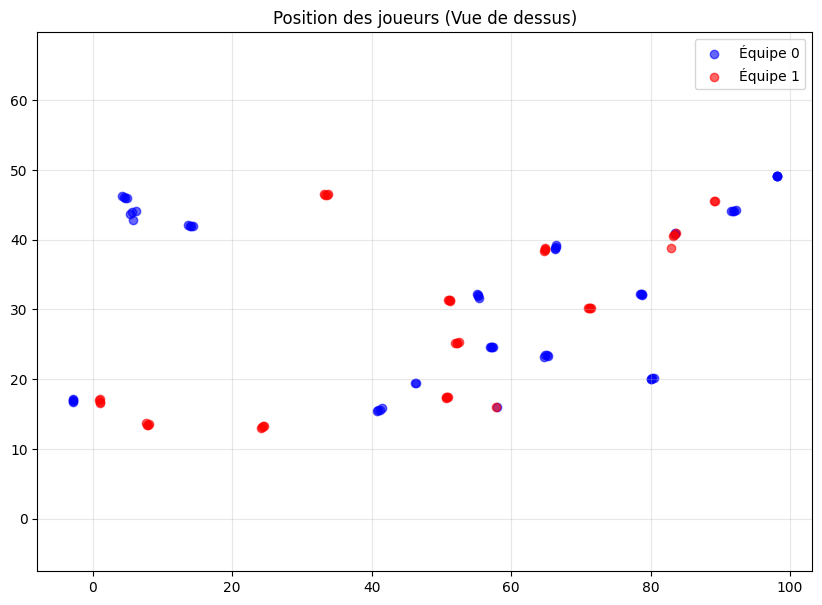

In [7]:
import matplotlib.pyplot as plt

# Vérification de sécurité
if not tracking_data:
    print("ERREUR")
else:
    df = pd.DataFrame(tracking_data)

    # Séparation des équipes
    team_0 = df[df['Team'] == 0]
    team_1 = df[df['Team'] == 1]

    plt.figure(figsize=(10, 7))
    plt.title("Position des joueurs (Vue de dessus)")

    plt.axis('equal') 
    
    # Affichage des points
    plt.scatter(team_0['X_2D'], team_0['Y_2D'], c='blue', alpha=0.6, label='Équipe 0')
    plt.scatter(team_1['X_2D'], team_1['Y_2D'], c='red', alpha=0.6, label='Équipe 1')

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Les résultats ici sont décevants car la vidéo n'est pas une vidéo avec un plan fixe du terrain. De plus, comme dit dans le notebook précédent, les mesures peu précises du terrain contribuent à ces résultats peu exploitables..